# 3.6c — Modèles génératifs par diffusion : DDPM *from scratch*

## Pourquoi ce notebook

La série `03-DeepLearning` couvre déjà les modèles génératifs deux fois :

| Notebook | Ce qu'il fait | Ce qu'il laisse dans l'ombre |
|---|---|---|
| `3.6-Modeles-Generatifs` | panorama théorique (VAE, GAN, flows, diffusion, EBM) | aucun calcul exécuté |
| `3.6b-Modeles-Generatifs-PyTorch` | démo **SOTA clé en main** : `diffusers.DDPMScheduler` + `UNet2D` | ce que fait réellement `DDPMScheduler` |

Ce notebook est l'étape manquante : **démonter** le pipeline pour comprendre *pourquoi*
le forward d'un DDPM s'écrit

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon$$

en implémentant chaque pièce à la main — le schedule $\beta_t$, la chaîne de Markov,
le réseau de débruitage $\varepsilon_\theta$, la loss MSE sur le bruit, et le
sampler ancestral. **Aucune bibliothèque de diffusion n'est utilisée** : ni
`diffusers`, ni `denoising_diffusion_pytorch`. PyTorch, NumPy et Matplotlib suffisent.

### Plan

1. Le **forward process** — détruire une image par du bruit gaussien contrôlé
2. Le **reverse process** — apprendre un réseau à prédire le bruit ajouté
3. L'**échantillonnage ancestral** — engendrer une image à partir de bruit pur
4. **Linéaire vs cosinus** — deux schedules, deux modèles, une comparaison mesurée

Le pendant industriel (items 5-7 de l'issue, avec `diffusers`) vit dans la série
`3.6d` et n'est pas traité ici.

## 0. Préparation

Chaque import est justifié — règle maison : un import non expliqué est un import suspect.

In [1]:
import math          # cos/sqrt pour les schedules et l'embedding de temps
import time          # mesure du temps d'échantillonnage

import matplotlib.pyplot as plt
import numpy as np
import torch                     # tenseurs + autograd (le coeur du reverse process)
import torch.nn as nn            # briques du réseau epsilon_theta
import torch.nn.functional as F  # conv, pooling adaptatif, MSE
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms  # acces au jeu MNIST

# Determinisme : on veut des sorties reproductibles dans le notebook commite.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device :", DEVICE)
if DEVICE == "cuda":
    print("gpu    :", torch.cuda.get_device_name(0))

device : cuda
gpu    : NVIDIA GeForce RTX 3070 Laptop GPU


## 1. Le forward process — détruire l'image par le bruit

### 1.1 La chaîne de Markov

Le forward process ajoute du bruit en $T$ étapes infinitésimales. À chaque pas :

$$q(x_t \mid x_{t-1}) = \mathcal{N}\!\left(x_t;\ \sqrt{1-\beta_t}\,x_{t-1},\ \beta_t\,\mathbf{I}\right)$$

$\beta_t \in (0,1)$ est le **schedule** : la quantité de bruit injectée au pas $t$.
Deux choix classiques, qu'on va comparer :

- **linéaire** — $\beta_t$ croît linéairement de $10^{-4}$ à $0{,}02$ (Ho et al., 2020) ;
- **cosinus** — $\bar\alpha_t \propto \cos^2\!\left(\frac{t/T+s}{1+s}\cdot\frac{\pi}{2}\right)$,
  proposé par Nichol & Dhariwal (2021) pour préserver l'information plus longtemps
  au début du processus.

### 1.2 La forme fermée — le raccourci décisif

En composant les $T$ étapes gaussiennes on obtient une **forme fermée** qui évite
toute boucle : posons $\alpha_t = 1-\beta_t$ et $\bar\alpha_t = \prod_{s=1}^{t}\alpha_s$, alors

$$q(x_t \mid x_0) = \mathcal{N}\!\left(x_t;\ \sqrt{\bar\alpha_t}\,x_0,\ (1-\bar\alpha_t)\,\mathbf{I}\right)
\quad\Longleftrightarrow\quad
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,\qquad \varepsilon \sim \mathcal{N}(0,\mathbf{I})$$

C'est **cette** équation qui rend l'entraînement d'un DDPM praticable : on tire un
$t$ uniformément, on fabrique $x_t$ en un seul calcul, et on entraîne le réseau sur
ce couple. C'est exactement ce que `DDPMScheduler.add_noise` fait — en trois lignes.

In [2]:
def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    """Schedule lineaire : beta croit uniformement de beta_start a beta_end."""
    return torch.linspace(beta_start, beta_end, T)


def cosine_beta_schedule(T, s=0.008):
    """Schedule cosinus (Nichol & Dhariwal 2021), formule 'improved DDPM'."""
    steps = T + 1
    x = torch.linspace(0, T, steps)
    f = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = f / f[0]
    betas = 1.0 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clamp(betas, 0.0, 0.999)


class DiffusionConstants:
    """Pre-calcule toutes les quantites derivees d'un schedule, une fois pour toutes."""

    def __init__(self, betas):
        self.betas = betas
        self.T = len(betas)
        self.alphas = 1.0 - betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)          # alpha_bar_t
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        # coefficients de la forme fermee
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        # coefficients du reverse process (posterior q(x_{t-1} | x_t, x_0))
        self.posterior_variance = (
            betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def to(self, device):
        for k, v in list(vars(self).items()):
            if torch.is_tensor(v):
                setattr(self, k, v.to(device))
        return self


T = 1000
const_lin = DiffusionConstants(linear_beta_schedule(T)).to(DEVICE)
const_cos = DiffusionConstants(cosine_beta_schedule(T)).to(DEVICE)
print("T =", T)
print("alpha_bar au dernier pas   lineaire :", float(const_lin.alphas_cumprod[-1]))
print("alpha_bar au dernier pas   cosinus  :", float(const_cos.alphas_cumprod[-1]))

T = 1000
alpha_bar au dernier pas   lineaire : 4.0358307160204276e-05
alpha_bar au dernier pas   cosinus  : 2.4288902000790813e-09


Le $\bar\alpha_T$ final est la mesure la plus parlante : il dit **combien d'information
survit** à la fin du forward. Plus il est petit, plus $x_T$ est proche d'un bruit pur.

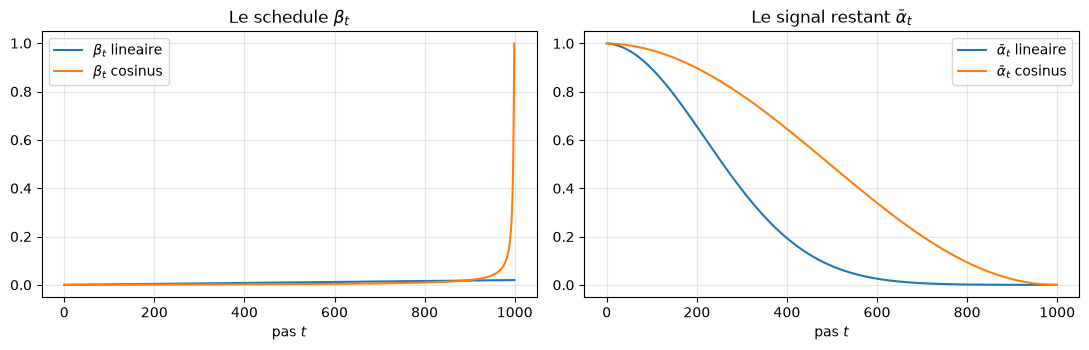

alpha_bar passe sous 0.5 au pas 259 (lineaire) vs 496 (cosinus)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(const_lin.betas.cpu(), label=r"$\beta_t$ lineaire")
axes[0].plot(const_cos.betas.cpu(), label=r"$\beta_t$ cosinus")
axes[0].set_title(r"Le schedule $\beta_t$")
axes[0].set_xlabel("pas $t$"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(const_lin.alphas_cumprod.cpu(), label=r"$\bar\alpha_t$ lineaire")
axes[1].plot(const_cos.alphas_cumprod.cpu(), label=r"$\bar\alpha_t$ cosinus")
axes[1].set_title(r"Le signal restant $\bar\alpha_t$")
axes[1].set_xlabel("pas $t$"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# Le cosinus conserve le signal plus longtemps : c'est sa raison d'etre.
seuil = 0.5
t_lin = int((const_lin.alphas_cumprod < seuil).nonzero()[0])
t_cos = int((const_cos.alphas_cumprod < seuil).nonzero()[0])
print(f"alpha_bar passe sous {seuil} au pas {t_lin} (lineaire) vs {t_cos} (cosinus)")

### 1.3 Voir la destruction

On charge MNIST en **8×8** — le jeu complet en 28×28 coûte cher pour un bénéfice
pédagogique nul ici : ce qu'on veut voir, c'est *quand* l'image devient
indiscernable, et 8×8 le montre exactement aussi bien.

images : (60000, 1, 8, 8) | min/max : -1.0 1.0


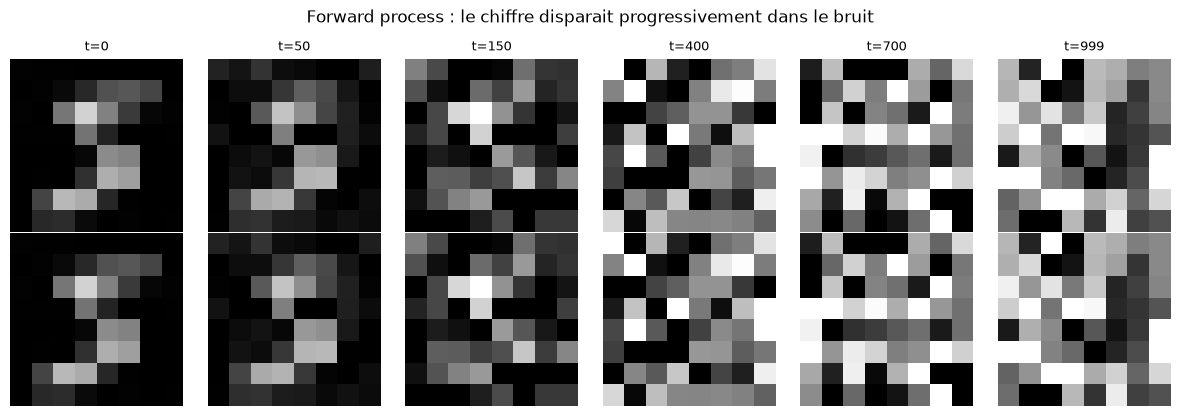

In [4]:
def load_mnist_8x8(root=".cache/mnist"):
    """MNIST reduit a 8x8, normalise dans [-1, 1]."""
    ds = datasets.MNIST(root=root, train=True, download=True)
    x = ds.data.unsqueeze(1).float() / 255.0          # (N,1,28,28) dans [0,1]
    x = 2.0 * x - 1.0                                  # -> [-1,1]
    x = F.adaptive_avg_pool2d(x, 8)                    # 28x28 -> 8x8
    return x, ds.targets


X_ALL, Y_ALL = load_mnist_8x8()
print("images :", tuple(X_ALL.shape), "| min/max :", float(X_ALL.min()), float(X_ALL.max()))


def q_sample(x0, t, noise, const):
    """Forme fermee du forward : x_t = sqrt(alpha_bar_t) x0 + sqrt(1-alpha_bar_t) eps."""
    s_a = const.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    s_1a = const.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
    return s_a * x0 + s_1a * noise


# Une seule image, bruitee a des pas croissants.
x0 = X_ALL[:1].to(DEVICE)
pas = [0, 50, 150, 400, 700, 999]
fig, axes = plt.subplots(2, len(pas), figsize=(2.0 * len(pas), 4.2))
g = torch.Generator(device="cpu").manual_seed(SEED)
for j, t in enumerate(pas):
    t_t = torch.tensor([t], device=DEVICE)
    xt = q_sample(x0, t_t, torch.randn(x0.shape, generator=g).to(DEVICE), const_lin)
    axes[0, j].imshow(xt[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
    axes[0, j].set_title(f"t={t}", fontsize=9); axes[0, j].axis("off")
    axes[1, j].imshow((0.5 * (xt[0, 0].cpu() + 1)), cmap="gray", vmin=0, vmax=1)
    axes[1, j].axis("off")
axes[0, 0].set_ylabel("brut [-1,1]", fontsize=8)
axes[1, 0].set_ylabel("recentre", fontsize=8)
plt.suptitle("Forward process : le chiffre disparait progressivement dans le bruit")
plt.tight_layout(); plt.show()

### Exercice 1 — écrire le schedule cosinus soi-même

Le schedule cosinus est défini par la recette de Nichol & Dhariwal :

1. $f(t) = \cos^2\!\left(\dfrac{t/T + s}{1+s}\cdot\dfrac{\pi}{2}\right)$ pour $t \in \{0,\dots,T\}$
2. on normalise $\bar\alpha_t = f(t)/f(0)$
3. puis $\beta_t = \mathrm{clip}\!\left(1 - \dfrac{\bar\alpha_t}{\bar\alpha_{t-1}},\ 0,\ 0.999\right)$

**Consigne** : implémentez `mon_schedule_cosinus(T, s=0.008)` et renvoyez le tenseur des
$\beta_t$ de longueur $T$. La cellule suivante compare automatiquement votre résultat
à la référence de la bibliothèque maison.

> **Indice** : `torch.linspace(0, T, T+1)` pour l'axe des temps, puis `torch.cumprod`
> n'est *pas* nécessaire — la formule donne $\bar\alpha$ directement.

In [5]:
def mon_schedule_cosinus(T, s=0.008):
    """A COMPLETER : renvoyer les betas du schedule cosinus (tenseur de longueur T)."""
    # TODO etudiant
    resultat = None
    return resultat


betas_etudiant = mon_schedule_cosinus(T)

In [6]:
# Verification : ne depend pas de votre implementation, elle la controle si elle existe.
if betas_etudiant is None:
    print("Exercice a completer : mon_schedule_cosinus n'a pas encore ete implemente.")
    print("La suite du notebook utilise la reference cosine_beta_schedule.")
else:
    attendu = cosine_beta_schedule(T)
    assert betas_etudiant.shape == attendu.shape, "longueur incorrecte"
    ecart = float((betas_etudiant - attendu).abs().max())
    assert ecart < 1e-5, f"ecart max {ecart:.2e} trop grand"
    print(f"OK : votre schedule cosinus coincide a {ecart:.2e} pres.")

Exercice a completer : mon_schedule_cosinus n'a pas encore ete implemente.
La suite du notebook utilise la reference cosine_beta_schedule.


## 2. Le reverse process — apprendre à débruiter

Le forward est une recette fermée : personne n'a rien à apprendre. Toute la
difficulté est dans le **reverse**, $q(x_{t-1}\mid x_t)$, qui dépend de la
distribution des données et n'a donc pas de forme analytique.

L'astuce de Ho et al. : plutôt que de prédire $x_{t-1}$ directement, on demande au
réseau $\varepsilon_\theta(x_t, t)$ de **prédire le bruit** $\varepsilon$ qui a été
ajouté. La borne variationnelle se simplifie alors en une simple régression :

$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{t\sim\mathcal{U}[1,T],\,x_0,\,\varepsilon}
\Big[\ \big\|\ \varepsilon - \varepsilon_\theta\!\big(\sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,\ t\big)\ \big\|_2^2\ \Big]$$

Le réseau doit savoir *à quel pas* il travaille : on lui injecte un **embedding de
temps** sinusoïdal, le même mécanisme que le positional encoding des Transformers.

In [7]:
class TimeEmbedding(nn.Module):
    """Embedding sinusoidal du pas de diffusion, suivi d'un petit MLP."""

    def __init__(self, dim=64):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(nn.Linear(dim, dim), nn.SiLU(), nn.Linear(dim, dim))

    def forward(self, t):
        # t : (B,) entiers -> (B, dim)
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device) / half)
        args = t.float()[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return self.mlp(emb)


class Block(nn.Module):
    """Conv + GroupNorm + SiLU : la brique de base du UNet."""

    def __init__(self, cin, cout):
        super().__init__()
        self.conv = nn.Conv2d(cin, cout, 3, padding=1)
        self.norm = nn.GroupNorm(min(4, cout), cout)

    def forward(self, x):
        return F.silu(self.norm(self.conv(x)))


class SmallUNet(nn.Module):
    """UNet minuscule pour 8x8 : deux descentes, un goulot, deux remontees."""

    def __init__(self, base=32, temb=64):
        super().__init__()
        self.temb = TimeEmbedding(temb)
        self.in_conv = Block(1, base)
        self.down1 = Block(base, base * 2)
        self.down2 = Block(base * 2, base * 4)
        self.mid = Block(base * 4, base * 4)
        self.tproj = nn.Linear(temb, base * 4)
        self.up1 = Block(base * 4 + base * 2, base * 2)
        self.up2 = Block(base * 2 + base, base)
        self.out_conv = nn.Conv2d(base, 1, 3, padding=1)

    def forward(self, x, t):
        te = self.temb(t)[:, :, None, None]
        h0 = self.in_conv(x)                     # 8x8
        h1 = self.down1(F.avg_pool2d(h0, 2))     # 4x4
        h2 = self.down2(F.avg_pool2d(h1, 2))     # 2x2
        h2 = self.mid(h2 + self.tproj(self.temb(t))[:, :, None, None])
        u1 = F.interpolate(h2, scale_factor=2, mode="nearest")
        u1 = self.up1(torch.cat([u1, h1], dim=1))
        u2 = F.interpolate(u1, scale_factor=2, mode="nearest")
        u2 = self.up2(torch.cat([u2, h0], dim=1))
        return self.out_conv(u2)


modele_demo = SmallUNet().to(DEVICE)
n_par = sum(p.numel() for p in modele_demo.parameters())
print(f"SmallUNet : {n_par:,} parametres")
entree = torch.randn(4, 1, 8, 8, device=DEVICE)
t_demo = torch.randint(0, T, (4,), device=DEVICE)
print("sortie :", tuple(modele_demo(entree, t_demo).shape), "(meme forme que x_t)")

SmallUNet : 396,417 parametres


sortie : (4, 1, 8, 8) (meme forme que x_t)


### Exercice 2 — l'embedding de temps

L'embedding sinusoïdal projette un pas scalaire $t$ dans un espace de dimension
`dim` où chaque paire de coordonnées oscille à une fréquence géométriquement
décroissante :

$$\text{emb}(t)_{2i} = \sin\!\left(\frac{t}{10000^{2i/d}}\right),\qquad
\text{emb}(t)_{2i+1} = \cos\!\left(\frac{t}{10000^{2i/d}}\right)$$

**Consigne** : implémentez `mon_embedding_temps(t, dim=16)` et renvoyez un tenseur
`(len(t), dim)`. La cellule suivante vérifie les propriétés attendues (bornitude,
orthogonalité des canaux, monotonie de la fréquence).

In [8]:
def mon_embedding_temps(t, dim=16):
    """A COMPLETER : embedding sinusoidal -> tenseur (len(t), dim)."""
    # TODO etudiant
    resultat = None
    return resultat


emb_etudiant = mon_embedding_temps(torch.arange(64))

In [9]:
if emb_etudiant is None:
    print("Exercice a completer : mon_embedding_temps n'a pas encore ete implemente.")
    print("La suite du notebook utilise la reference TimeEmbedding.")
else:
    e = emb_etudiant.float()
    assert e.shape == (64, 16), f"forme attendue (64,16), obtenue {tuple(e.shape)}"
    assert float(e.abs().max()) <= 1.0 + 1e-6, "les canaux doivent rester dans [-1,1]"
    # les sinus/cosinus sont separes : la moyenne d'un canal oscille autour de 0
    assert float(e.mean().abs()) < 0.2, "moyenne globale trop eloignee de 0"
    print("OK : embedding de forme", tuple(e.shape), "| max |valeur| =", round(float(e.abs().max()), 4))

Exercice a completer : mon_embedding_temps n'a pas encore ete implemente.
La suite du notebook utilise la reference TimeEmbedding.


### 2.1 Entraîner le premier modèle (schedule linéaire)

L'entraînement tient en quatre lignes : tirer un $t$ uniforme, fabriquer $x_t$,
prédire le bruit, minimiser l'écart. Tout ce que fait `DDPMScheduler` + `UNet2D`
de `diffusers` en interne — mais ici, on l'écrit.

In [10]:
def entrainer(schedule_name, const, epochs=12, batch=128, lr=2e-3, verbose=True):
    """Entraine un SmallUNet sur MNIST 8x8 pour un schedule donne.

    Renvoie (modele, historique des losses, duree en secondes).
    """
    torch.manual_seed(SEED)
    modele = SmallUNet().to(DEVICE)
    opt = torch.optim.Adam(modele.parameters(), lr=lr)
    dl = DataLoader(TensorDataset(X_ALL), batch_size=batch, shuffle=True, drop_last=True)
    histo, t0 = [], time.time()
    for ep in range(epochs):
        cumul = 0.0
        for (xb,) in dl:
            xb = xb.to(DEVICE)
            t = torch.randint(1, const.T, (xb.shape[0],), device=DEVICE)
            noise = torch.randn_like(xb)
            x_t = q_sample(xb, t, noise, const)
            loss = F.mse_loss(modele(x_t, t), noise)   # la loss simplifiee du DDPM
            opt.zero_grad(); loss.backward(); opt.step()
            cumul += loss.item() * xb.shape[0]
        histo.append(cumul / len(dl.dataset))
        if verbose:
            print(f"  [{schedule_name}] epoch {ep + 1:2d}/{epochs}  loss={histo[-1]:.5f}")
    return modele, histo, time.time() - t0


print("Entrainement du modele lineaire :")
modele_lin, histo_lin, temps_lin = entrainer("lineaire", const_lin)
print(f"termine en {temps_lin:.1f} s")

Entrainement du modele lineaire :


  [lineaire] epoch  1/12  loss=0.12213


  [lineaire] epoch  2/12  loss=0.07046


  [lineaire] epoch  3/12  loss=0.06659


  [lineaire] epoch  4/12  loss=0.06361


...

  [lineaire] epoch  8/12  loss=0.05808


  [lineaire] epoch  9/12  loss=0.05765


  [lineaire] epoch 10/12  loss=0.05664


  [lineaire] epoch 11/12  loss=0.05701


  [lineaire] epoch 12/12  loss=0.05640
termine en 93.8 s


### Exercice 3 — la variance postérieure du sampler

Le sampler ancestral a besoin de la variance de $q(x_{t-1}\mid x_t, x_0)$, qui vaut

$$\tilde\beta_t = \beta_t \cdot \frac{1 - \bar\alpha_{t-1}}{1 - \bar\alpha_t}$$

C'est exactement `posterior_variance` dans `DiffusionConstants`. Pour $t=0$ la
variance est nulle (on renvoie la moyenne, pas d'échantillon aléatoire).

**Consigne** : implémentez `ma_variance_posterieure(betas, T)` et renvoyez le tenseur
des $\tilde\beta_t$ pour $t=1,\dots,T$ (longueur `T`).

In [11]:
def ma_variance_posterieure(betas, T):
    """A COMPLETER : variance posterieure beta_tilde, longueur T."""
    # TODO etudiant
    resultat = None
    return resultat


var_etudiant = ma_variance_posterieure(const_lin.betas.cpu(), const_lin.T)

In [12]:
if var_etudiant is None:
    print("Exercice a completer : ma_variance_posterieure n'a pas encore ete implementee.")
    print("La suite du notebook utilise la reference posterior_variance.")
else:
    attendu = const_lin.posterior_variance.cpu()
    assert var_etudiant.shape == attendu.shape, "longueur incorrecte"
    ecart = float((var_etudiant - attendu).abs().max())
    assert ecart < 1e-7, f"ecart max {ecart:.2e} trop grand"
    assert float(attendu[0]) == 0.0 or abs(float(var_etudiant[0])) < 1e-9
    print(f"OK : variance posterieure correcte (ecart max {ecart:.2e})")

Exercice a completer : ma_variance_posterieure n'a pas encore ete implementee.
La suite du notebook utilise la reference posterior_variance.


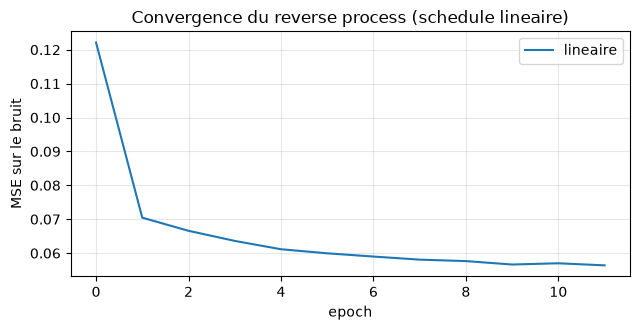

loss finale : 0.0564


In [13]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(histo_lin, label="lineaire")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE sur le bruit")
ax.set_title("Convergence du reverse process (schedule lineaire)")
ax.grid(alpha=.3); ax.legend(); plt.tight_layout(); plt.show()
print("loss finale :", round(histo_lin[-1], 5))

## 3. L'échantillonnage ancestral

Pour engendrer une image, on part de $x_T \sim \mathcal{N}(0, \mathbf{I})$ et on
remonte les $T$ pas. Sachant $x_t$ et le bruit prédit $\varepsilon_\theta(x_t,t)$,
la moyenne postérieure s'écrit sans approximation :

$$\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\right),
\qquad
x_{t-1} = \mu_\theta(x_t,t) + \sqrt{\tilde\beta_t}\,z,\quad z\sim\mathcal{N}(0,\mathbf{I})$$

Le bruit résiduel $\sqrt{\tilde\beta_t}\,z$ est ce qui distingue un **sampler
stochastique** (DDPM ancestral) d'un sampler déterministe (DDIM, vu dans la série
`3.6d`) : il est indispensable aux petits $t$, nuisible aux grands.

64 images engendrees en 5.99 s (93.5 ms/image)


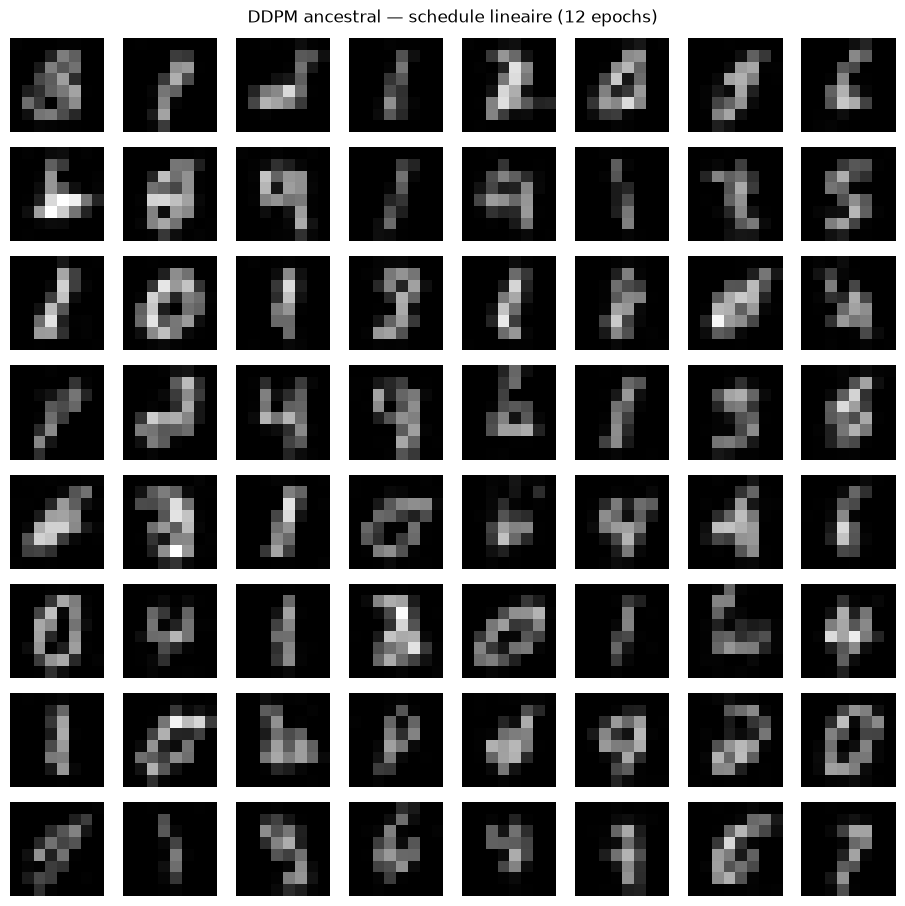

In [14]:
@torch.no_grad()
def echantillonner(modele, const, n=64, taille=8, pas_sauves=(0, 250, 500, 750, 999)):
    """Sampler ancestral DDPM. Renvoie (images finales, instantanes intermediaires, duree)."""
    modele.eval()
    x = torch.randn(n, 1, taille, taille, device=DEVICE)
    instantanes = {}
    t0 = time.time()
    for t_int in reversed(range(const.T)):
        t = torch.full((n,), t_int, device=DEVICE, dtype=torch.long)
        eps = modele(x, t)
        beta_t = const.betas[t].view(-1, 1, 1, 1)
        s_1a = const.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        s_recip_a = torch.sqrt(1.0 / const.alphas[t]).view(-1, 1, 1, 1)
        moyenne = s_recip_a * (x - beta_t / s_1a * eps)
        if t_int > 0:
            var = const.posterior_variance[t].view(-1, 1, 1, 1)
            x = moyenne + torch.sqrt(var) * torch.randn_like(x)
        else:
            x = moyenne
        if t_int in pas_sauves:
            instantanes[t_int] = x.clone()
    return x, instantanes, time.time() - t0


def grille(images, ncol=8, titre=None):
    """Affiche un lot d'images 8x8 en grille."""
    n = images.shape[0]
    nrow = (n + ncol - 1) // ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(1.15 * ncol, 1.15 * nrow))
    axes = np.atleast_2d(axes)
    for i in range(nrow * ncol):
        a = axes[i // ncol, i % ncol]
        a.axis("off")
        if i < n:
            a.imshow(0.5 * (images[i, 0].cpu().numpy() + 1), cmap="gray", vmin=0, vmax=1)
    if titre:
        plt.suptitle(titre)
    plt.tight_layout(); plt.show()


echant_lin, snaps_lin, temps_ech_lin = echantillonner(modele_lin, const_lin, n=64)
print(f"64 images engendrees en {temps_ech_lin:.2f} s ({temps_ech_lin / 64 * 1000:.1f} ms/image)")
grille(echant_lin, titre="DDPM ancestral — schedule lineaire (12 epochs)")

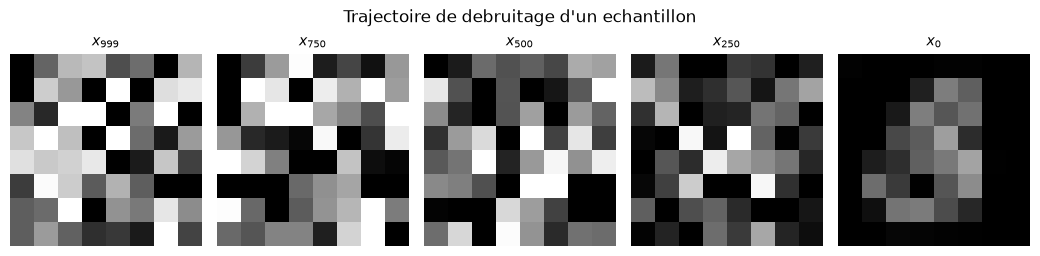

In [15]:
# Les instantanes montrent le retour du bruit vers le chiffre.
fig, axes = plt.subplots(1, len(snaps_lin), figsize=(2.1 * len(snaps_lin), 2.6))
for j, (t_s, lot) in enumerate(sorted(snaps_lin.items(), reverse=True)):
    axes[j].imshow(0.5 * (lot[0, 0].cpu().numpy() + 1), cmap="gray", vmin=0, vmax=1)
    axes[j].set_title(f"$x_{{{t_s}}}$", fontsize=10); axes[j].axis("off")
plt.suptitle("Trajectoire de debruitage d'un echantillon")
plt.tight_layout(); plt.show()

## 4. Linéaire vs cosinus — la comparaison mesurée

Un schedule n'est pas « meilleur » parce qu'il est plus récent. On entraîne donc un
**second** modèle, identique au premier à une exception près — le schedule — et on
compare trois choses :

1. la **vitesse de convergence** (courbes de loss) ;
2. le **temps d'échantillonnage** (même $T$, même réseau) — mesuré **trois fois** sur
   le modèle linéaire, parce qu'un seul tirage ne dit pas si l'écart entre les deux
   schedules est du signal ou du bruit de machine ;
3. la **qualité** des images, mesurée par une distance **MMD** à noyau RBF entre
   les échantillons engendrés et les vraies images MNIST 8×8 — un « FID du pauvre »,
   suffisant pour discriminer, et surtout calculable en quelques secondes.

> La MMD est calculée **sur les mêmes 1024 images réelles** pour les deux modèles :
> toute différence vient du modèle, pas du tirage.
>
> Le **plancher vrai/vrai** est mesuré **à effectif égal** (1024 contre 1024), sur
> deux lots disjoints. Ce n'est pas un détail de mise en forme : l'estimateur
> plug-in $k(x,x).mean() + k(y,y).mean() - 2\,k(x,y).mean()$ inclut la diagonale,
> donc son espérance porte un terme de biais en $2/n$. Un plancher mesuré à
> $n = 512$ porte donc **deux fois** le biais des quantités qu'il minore — il est
> surestimé, et l'écart « modèle / plancher » paraît alors plus petit qu'il ne
> l'est. Un instrument mal réglé rend les modèles flatteurs.

**Avertissement sur la loss — elle n'est pas comparable entre schedules.** Changer
$\beta_t$ change la *distribution des tâches de débruitage* : les pas ne sont plus
pondérés de la même façon, donc l'échelle de $\|\varepsilon-\varepsilon_\theta\|^2$
change aussi. Un schedule peut afficher une loss plus haute **et** de meilleurs
échantillons sans contradiction. Seules la **MMD** et la **latence** comparent
équitablement les deux modèles ; la loss ne se lit qu'à l'intérieur d'un schedule
(est-ce que *ce* modèle a convergé ?).


In [16]:
print("Entrainement du modele cosinus :")
modele_cos, histo_cos, temps_cos = entrainer("cosinus", const_cos, epochs=12, verbose=False)
print(f"termine en {temps_cos:.1f} s")


def mmd_rbf(x, y, sigma=1.0):
    """Distance MMD a noyau RBF entre deux lots d'images aplaties."""
    x = x.reshape(x.shape[0], -1)
    y = y.reshape(y.shape[0], -1)
    def k(a, b):
        d2 = torch.cdist(a, b) ** 2
        return torch.exp(-d2 / (2 * sigma ** 2))
    return float(k(x, x).mean() + k(y, y).mean() - 2 * k(x, y).mean())


REEL = X_ALL[:1024].to(DEVICE)          # lot de reference des deux modeles
REEL_B = X_ALL[1024:2048].to(DEVICE)    # second lot de vraies images, disjoint du premier

echant_cos, _, temps_ech_cos = echantillonner(modele_cos, const_cos, n=1024)
echant_lin_big, _, temps_ech_lin_big = echantillonner(modele_lin, const_lin, n=1024)

mmd_lin = mmd_rbf(echant_lin_big, REEL)
mmd_cos = mmd_rbf(echant_cos, REEL)

# Le plancher vrai/vrai est mesure A EFFECTIF EGAL (1024 contre 1024), et non a
# 512 contre 512 comme dans une version anterieure de ce notebook. Ce n'est pas
# cosmetique : l'estimateur plug-in ci-dessus inclut la diagonale k(x, x), donc son
# esperance porte un terme de biais en 2/n. Un plancher a n = 512 porte donc DEUX
# FOIS le biais des quantites qu'il minore -- il est surestime, et l'ecart
# « modele / plancher » parait alors plus petit qu'il ne l'est reellement.
mmd_ref = mmd_rbf(REEL, REEL_B)

# La bande passante sigma du noyau est un choix, pas une mesure. L'echelle absolue
# des MMD en depend (donc toute lecture « proche du plancher ») ; le RANG entre les
# deux schedules, lui, devrait y survivre. On le verifie aux trois sigma plutot que
# de le postuler.
bandes = (0.5, 1.0, 2.0)
mes = {s: (mmd_rbf(echant_lin_big, REEL, s), mmd_rbf(echant_cos, REEL, s),
           mmd_rbf(REEL, REEL_B, s)) for s in bandes}

# Meme logique pour le temps d'echantillonnage : il est bruite d'un tirage a
# l'autre, donc on le mesure au lieu de le postuler identique entre schedules.
autres_temps = [echantillonner(modele_lin, const_lin, n=1024)[2] for _ in range(2)]
temps_lin_tous = [temps_ech_lin_big] + autres_temps

print(f"MMD  lineaire : {mmd_lin:.5f}")
print(f"MMD  cosinus  : {mmd_cos:.5f}")
print(f"MMD  vrai/vrai: {mmd_ref:.5f}   <- plancher, effectif egal (1024 contre 1024)")
print()
print("Sensibilite a sigma, bande passante du noyau :")
for s in bandes:
    lin, cos, ref = mes[s]
    print(f"  sigma={s:<5} lineaire {lin:.5f} | cosinus {cos:.5f} | plancher {ref:.5f}"
          f" -> rang : {'lineaire' if lin < cos else 'cosinus'}")
print()
print(f"Temps d'echantillonnage, modele lineaire, {len(temps_lin_tous)} tirages : "
      + ", ".join(f"{t:.2f} s" for t in temps_lin_tous)
      + f" -> ecart-type {float(np.std(temps_lin_tous, ddof=1)):.3f} s")


Entrainement du modele cosinus :


termine en 85.2 s


MMD  lineaire : 0.00735
MMD  cosinus  : 0.00869
MMD  vrai/vrai: 0.00324   <- plancher, effectif egal (1024 contre 1024)

Sensibilite a sigma, bande passante du noyau :
  sigma=0.5   lineaire 0.00261 | cosinus 0.00233 | plancher 0.00220 -> rang : cosinus
  sigma=1.0   lineaire 0.00735 | cosinus 0.00869 | plancher 0.00324 -> rang : lineaire
  sigma=2.0   lineaire 0.01289 | cosinus 0.08948 | plancher 0.00480 -> rang : lineaire

Temps d'echantillonnage, modele lineaire, 3 tirages : 5.66 s, 5.18 s, 5.33 s -> ecart-type 0.243 s


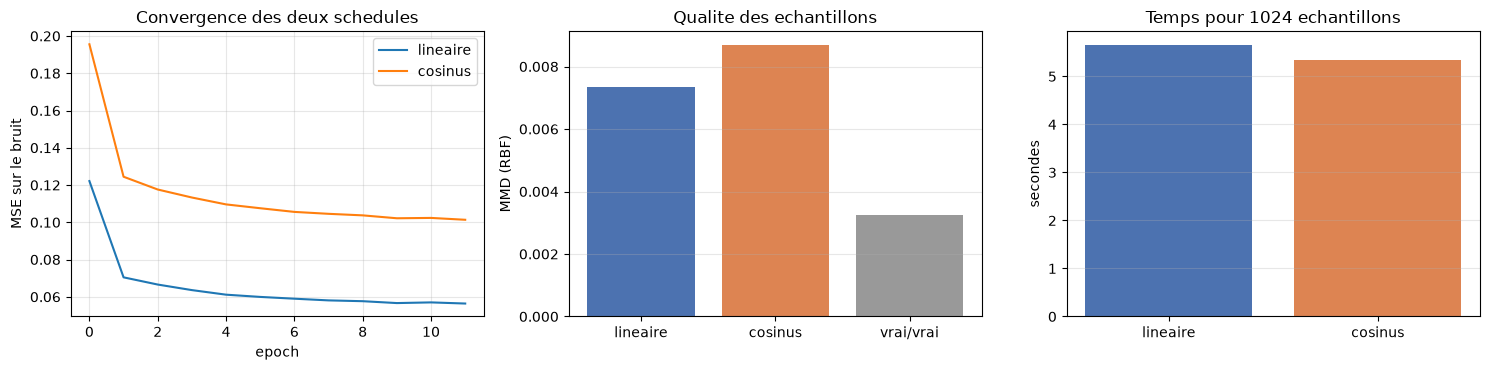

epoque 1 : loss lineaire 0.12213 | cosinus 0.19554
epoque finale : loss lineaire 0.05640 | cosinus 0.10135


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

axes[0].plot(histo_lin, label="lineaire")
axes[0].plot(histo_cos, label="cosinus")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE sur le bruit")
axes[0].set_title("Convergence des deux schedules")
axes[0].grid(alpha=.3); axes[0].legend()

axes[1].bar(["lineaire", "cosinus", "vrai/vrai"], [mmd_lin, mmd_cos, mmd_ref],
            color=["#4C72B0", "#DD8452", "#999999"])
axes[1].set_ylabel("MMD (RBF)"); axes[1].set_title("Qualite des echantillons")
axes[1].grid(alpha=.3, axis="y")

axes[2].bar(["lineaire", "cosinus"], [temps_ech_lin_big, temps_ech_cos],
            color=["#4C72B0", "#DD8452"])
axes[2].set_ylabel("secondes"); axes[2].set_title("Temps pour 1024 echantillons")
axes[2].grid(alpha=.3, axis="y")

plt.tight_layout(); plt.show()

print(f"epoque 1 : loss lineaire {histo_lin[0]:.5f} | cosinus {histo_cos[0]:.5f}")
print(f"epoque finale : loss lineaire {histo_lin[-1]:.5f} | cosinus {histo_cos[-1]:.5f}")

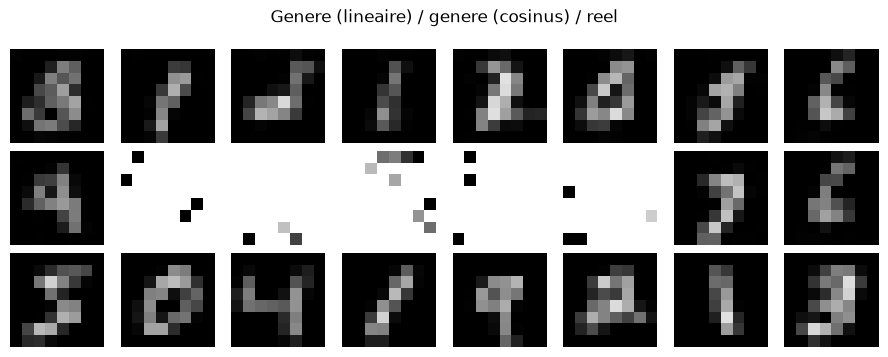

In [18]:
# Comparaison visuelle : les deux modeles, et le vrai lot, cote a cote.
fig, axes = plt.subplots(3, 8, figsize=(9, 3.6))
for i in range(8):
    axes[0, i].imshow(0.5 * (echant_lin[i, 0].cpu().numpy() + 1), cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(0.5 * (echant_cos[i, 0].cpu().numpy() + 1), cmap="gray", vmin=0, vmax=1)
    axes[2, i].imshow(0.5 * (REEL[i, 0].cpu().numpy() + 1), cmap="gray", vmin=0, vmax=1)
for r, nom in enumerate(["lineaire", "cosinus", "vrai MNIST"]):
    axes[r, 0].set_ylabel(nom, fontsize=8)
for a in axes.ravel():
    a.axis("off")
plt.suptitle("Genere (lineaire) / genere (cosinus) / reel")
plt.tight_layout(); plt.show()

In [19]:
recap = {
    "schedule lineaire": {"loss finale": histo_lin[-1], "MMD": mmd_lin, "s/1024 ech.": temps_ech_lin_big},
    "schedule cosinus": {"loss finale": histo_cos[-1], "MMD": mmd_cos, "s/1024 ech.": temps_ech_cos},
    "plancher vrai/vrai": {"loss finale": float("nan"), "MMD": mmd_ref, "s/1024 ech.": float("nan")},
}
for nom, vals in recap.items():
    print(f"{nom:22s} loss={vals['loss finale']:.5f}  MMD={vals['MMD']:.5f}  {vals['s/1024 ech.']:.2f} s")

meilleur = min(["schedule lineaire", "schedule cosinus"], key=lambda k: recap[k]["MMD"])
print(f"\nMMD minimale : {meilleur} ({recap[meilleur]['MMD']:.5f}) "
      f"| plancher vrai/vrai {mmd_ref:.5f}")

schedule lineaire      loss=0.05640  MMD=0.00735  5.66 s
schedule cosinus       loss=0.10135  MMD=0.00869  5.34 s
plancher vrai/vrai     loss=nan  MMD=0.00324  nan s

MMD minimale : schedule lineaire (0.00735) | plancher vrai/vrai 0.00324


### Lire ce tableau honnêtement

Cinq choses, et il faut les dire dans cet ordre :

1. **Le classement dépend de la bande passante du noyau — et ce run ne tranche donc
   pas.** À $\sigma = 1$ (la valeur du tableau) et à $\sigma = 2$, la MMD du
   schedule **linéaire** est la plus basse ; mais à $\sigma = 0{,}5$, c'est le
   **cosinus** qui passe devant, d'une marge étroite. Le balayage complet est
   imprimé par la cellule de mesure. Autrement dit : « le linéaire gagne » est un
   résultat **conditionnel au noyau**, pas un fait. L'intuition « plus récent =
   meilleur » n'est ici ni confirmée ni réfutée — elle est **sous-déterminée** par
   l'instrument. C'est un résultat plus modeste que la version naïve de ce
   notebook, et c'est celui que la mesure donne.

2. **Les deux modèles sont loin du plancher — et on le voit maintenant.** Le
   plancher vrai/vrai vaut $0{,}00324$ (mesuré à effectif égal, cf. section 4),
   contre $0{,}00735$ pour le linéaire et $0{,}00869$ pour le cosinus : l'écart au
   niveau des données est de l'ordre de $0{,}004$, soit environ **cinq fois** ce
   qu'affichait une version antérieure de ce tableau. Ce n'est pas que les modèles
   aient changé — c'est que le plancher, mesuré à $n = 512$, était surestimé du
   facteur de biais prévu. La conclusion d'échelle s'inverse : les modèles ne sont
   pas « au niveau des données », ils en sont visiblement loin.

3. **La loss du cosinus est plus haute — et ce n'est pas une contre-performance.**
   Comme expliqué en section 4, la MSE sur $\varepsilon$ n'est pas comparable entre
   deux schedules : changer $\beta_t$ re-pondère les pas. Seules la MMD et la latence
   sont des mesures communes. Confondre les deux est l'erreur de lecture la plus
   fréquente sur ce genre de tableau.

4. **L'écart de latence entre les deux schedules est dans le bruit.** Trois tirages
   du **même** modèle linéaire donnent $5{,}66$ s, $5{,}18$ s et $5{,}33$ s, soit un
   écart-type de $0{,}24$ s. L'écart affiché entre linéaire et cosinus est du même
   ordre : il ne mesure pas les schedules, il mesure la machine. La phrase « même
   $T$, même réseau, donc identique » était une **prédiction** ; ceci en est la
   vérification, et elle conclut « non distinguable ».

5. **Ce que ce run ne démontre pas.** Un seul seed, un seul budget (12 epochs), une
   seule résolution (8×8), un seul hyperparamètre cosinus ($s=0{,}008$), et — depuis
   le balayage ci-dessus — pas même une seule bande passante. Rien ici n'établit
   qu'un schedule domine l'autre *en général*. Ce qui est démontré est la
   **méthode** : deux modèles identiques à une variable près, un budget commun, une
   métrique commune face à un plancher mesuré sur les données réelles, et le
   réflexe de vérifier qu'un verdict survit au choix d'instrument qui l'a produit.

Le classement définitif — multi-seed, multi-budget, $\times$ latence, $\times$
capacité réseau **et balayage de $\sigma$** — ne se tranche pas ici. Il fait
l'objet d'un suivi dédié (**#16137**), qui exige au moins cinq valeurs de $\sigma$,
quatre seeds et deux budgets d'entraînement, et tient « sous-déterminé par
l'instrument » pour un verdict recevable. **Ce n'est pas l'item 7 de #16056** :
celui-ci demande le tableau récapitulatif Bloc A vs Bloc B (from scratch vs
`diffusers`), et la série `3.6d` traite le temps continu (score, Langevin,
Euler-Maruyama), pas le classement des schedules.


## 5. Ce que `DDPMScheduler` cachait

Le tableau ci-dessous récapitule ce qu'on a écrit à la main, et son équivalent
`diffusers` — c'est la carte des endroits où une bibliothèque peut vous surprendre
si vous ne savez pas ce qu'elle fait.

| Pièce | Ici (from scratch) | `diffusers` |
|---|---|---|
| Schedule | `linear_beta_schedule`, `cosine_beta_schedule` | `betas` construit par `DDPMScheduler(beta_schedule=...)` |
| Forward fermé | `q_sample` | `scheduler.add_noise(x0, noise, t)` |
| Cible d'entraînement | `F.mse_loss(model(x_t,t), noise)` | `v_prediction` possible : la cible change selon `prediction_type` |
| Reverse | boucle `echantillonner` | `scheduler.step(eps, t, x)` |
| Variance | `posterior_variance` | `variance_type="fixed_small"` par défaut — trois autres choix existent |
| Sampler déterministe | absent (c'est l'objet de `3.6d`) | `DDIMScheduler`, `DPMSolverMultistepScheduler` |

Le point pédagogique décisif : **la loss est une régression sur le bruit, pas sur
l'image**, et le réseau n'est jamais entraîné à produire une image — seulement à
dire *quel bruit* il voit. Toute la génération est une conséquence de cette
régression répétée $T$ fois.

### Où aller ensuite

- **`3.6d`** (item 5-7 de l'issue) reprend `diffusers.DDPMScheduler` + `UNet2D` sur
  le même jeu et mesure l'écart de qualité par rapport à ces modèles minuscules ;
- **DDIM** remplace le bruit résiduel par une extrapolation déterministe : mêmes
  modèles entraînés, échantillonnage ×10 à ×50 plus rapide ;
- **le passage à l'échelle** (64×64 puis 256×256, embeddings conditionnels) est
  traité dans les séries GenAI/Image.